--- PIPELINE CAPACITY PROJECTIONS (MW) ---
 Year  Annual_P10_MW  Annual_P50_MW  Annual_P90_MW  Cum_P10_MW  Cum_P50_MW  Cum_P90_MW
 2026          150.0          350.0          350.0       150.0       350.0       350.0
 2027          300.0          300.0          375.0       425.0       575.0       725.0
 2028            0.0          250.0          370.0       500.0       770.0       975.0
 2029            0.0            0.0          180.0       550.0       855.0      1080.0


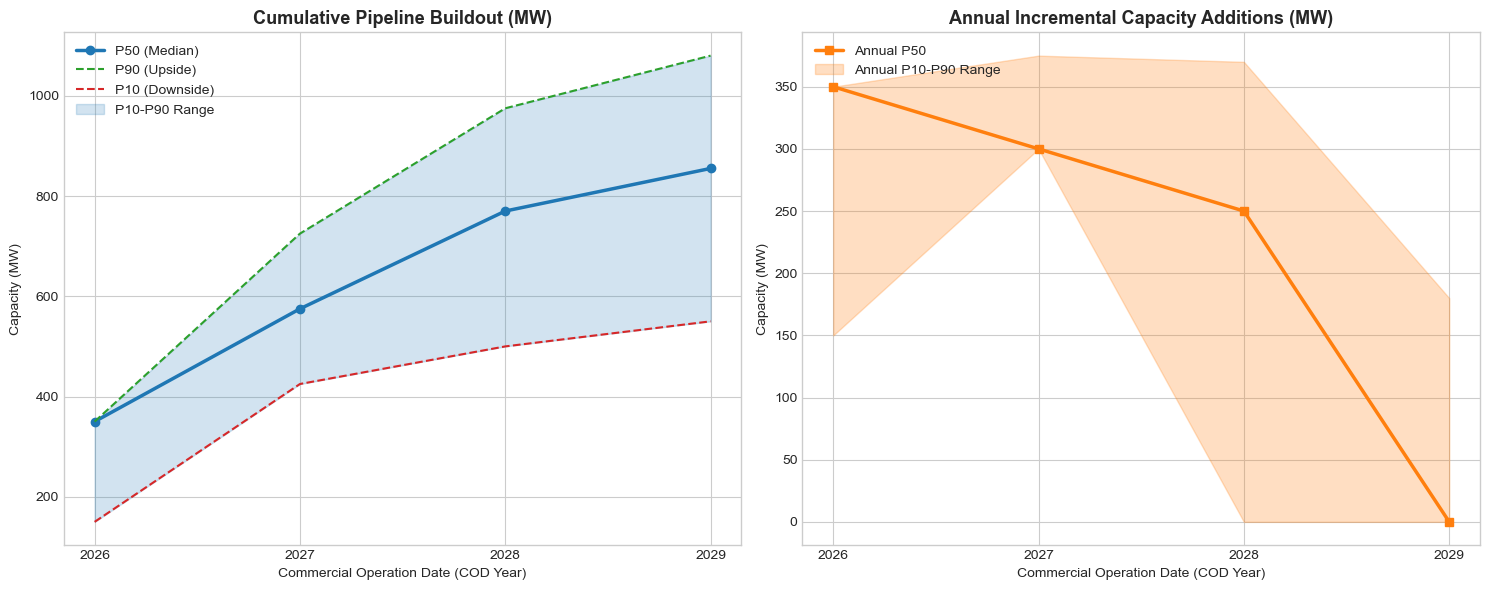

In [1]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import beta

# -----------------------------------------------------------------------------
# 1. GENERATE DUMMY PIPELINE DATA (Skip if loading your own CSV)
# -----------------------------------------------------------------------------
csv_data = """Project_ID,Capacity_MW,COD_Year,Stage,P_Built_Base,Capex_mUSD
PRJ-001,150,2026,Permitting,0.85,180
PRJ-002,200,2026,Interconnection,0.60,230
PRJ-003,75,2027,Early Stage,0.30,95
PRJ-004,300,2027,Construction,0.95,340
PRJ-005,120,2028,Early Stage,0.25,140
PRJ-006,250,2028,Permitting,0.70,290
PRJ-007,180,2029,Early Stage,0.40,210
"""

# Load CSV (Replace io.StringIO(csv_data) with 'your_pipeline.csv')
df = pd.read_csv(io.StringIO(csv_data))

# -----------------------------------------------------------------------------
# 2. MONTE CARLO SIMULATION CONFIGURATION
# -----------------------------------------------------------------------------
NUM_SIMULATIONS = 10_000
BETA_VARIANCE_WEIGHT = 10  # Concentration parameter (higher = lower variance around P_Built_Base)

# Target timeline range
years = np.array(sorted(df["COD_Year"].unique()))
n_years = len(years)
n_projects = len(df)

# Matrix to hold total capacity per year per simulation run: Shape = (N_Sims, N_Years)
sim_capacity_matrix = np.zeros((NUM_SIMULATIONS, n_years))

# -----------------------------------------------------------------------------
# 3. VECTORIZED SIMULATION ENGINE
# -----------------------------------------------------------------------------
np.random.seed(42)  # For reproducibility

# A. Sample project-specific P(built) from Beta distribution
# Parametrizing Beta(alpha, beta) using base probability as the mean
alpha_params = df["P_Built_Base"].values * BETA_VARIANCE_WEIGHT
beta_params = (1 - df["P_Built_Base"].values) * BETA_VARIANCE_WEIGHT

# Draw probabilities: Shape = (NUM_SIMULATIONS, N_Projects)
p_built_draws = beta.rvs(
    alpha_params, beta_params, size=(NUM_SIMULATIONS, n_projects)
)

# B. Evaluate Bernoulli trial (Build vs. No-Build)
build_success = np.random.uniform(size=(NUM_SIMULATIONS, n_projects)) < p_built_draws

# C. Calculate capacity added per project
capacities = df["Capacity_MW"].values
realized_capacity = build_success * capacities  # Broadcast multiplication

# D. Aggregate capacity across projects by COD Year
for idx, year in enumerate(years):
    year_mask = (df["COD_Year"].values == year).astype(int)
    # Sum capacity for projects coming online in 'year'
    sim_capacity_matrix[:, idx] = np.dot(realized_capacity, year_mask)

# E. Compute Cumulative Additions across time
sim_cumulative_matrix = np.cumsum(sim_capacity_matrix, axis=1)

# -----------------------------------------------------------------------------
# 4. PERCENTILE EXTRACTION (P10 / P50 / P90)
# -----------------------------------------------------------------------------
# Note: P90 represents upside (90th percentile of capacity), P10 represents downside.
p10_annual = np.percentile(sim_capacity_matrix, 10, axis=0)
p50_annual = np.percentile(sim_capacity_matrix, 50, axis=0)
p90_annual = np.percentile(sim_capacity_matrix, 90, axis=0)

p10_cum = np.percentile(sim_cumulative_matrix, 10, axis=0)
p50_cum = np.percentile(sim_cumulative_matrix, 50, axis=0)
p90_cum = np.percentile(sim_cumulative_matrix, 90, axis=0)

# Summary DataFrame
summary_df = pd.DataFrame(
    {
        "Year": years,
        "Annual_P10_MW": p10_annual,
        "Annual_P50_MW": p50_annual,
        "Annual_P90_MW": p90_annual,
        "Cum_P10_MW": p10_cum,
        "Cum_P50_MW": p50_cum,
        "Cum_P90_MW": p90_cum,
    }
)

print("--- PIPELINE CAPACITY PROJECTIONS (MW) ---")
print(summary_df.to_string(index=False))
# -----------------------------------------------------------------------------
# 5. VISUALIZATION (FAN CHART)
# -----------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Cumulative Capacity Buildout (Fan Chart)
ax[0].plot(years, p50_cum, color="#1f77b4", marker="o", linewidth=2.5, label="P50 (Median)")
ax[0].plot(years, p90_cum, color="#2ca02c", linestyle="--", linewidth=1.5, label="P90 (Upside)")
ax[0].plot(years, p10_cum, color="#d62728", linestyle="--", linewidth=1.5, label="P10 (Downside)")

# Shaded uncertainty band (P10-P90)
ax[0].fill_between(years, p10_cum, p90_cum, color="#1f77b4", alpha=0.2, label="P10-P90 Range")

ax[0].set_title("Cumulative Pipeline Buildout (MW)", fontsize=13, fontweight="bold")
ax[0].set_xlabel("Commercial Operation Date (COD Year)")
ax[0].set_ylabel("Capacity (MW)")
ax[0].set_xticks(years)
ax[0].legend(loc="upper left")

# Chart 2: Annual Additions (Box/Band)
ax[1].plot(years, p50_annual, color="#ff7f0e", marker="s", linewidth=2.5, label="Annual P50")
ax[1].fill_between(years, p10_annual, p90_annual, color="#ff7f0e", alpha=0.25, label="Annual P10-P90 Range")

ax[1].set_title("Annual Incremental Capacity Additions (MW)", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Commercial Operation Date (COD Year)")
ax[1].set_ylabel("Capacity (MW)")
ax[1].set_xticks(years)
ax[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

In [3]:
# src/01_ingest_load.py
import requests, pandas as pd, time, yaml
cfg = yaml.safe_load(open("config.yaml"))
KEY = cfg["eia_api_key"]; BA = cfg["balancing_authority"]  # "DOM"
url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"
rows, offset = [], 0
while True:
    p = {"api_key": KEY, "frequency": "hourly", "data[0]": "value",
         "facets[respondent][]": BA, "facets[type][]": "D",
         "start": "2018-07-01T00", "end": "2025-06-30T23",
         "sort[0][column]": "period", "sort[0][direction]": "asc",
         "offset": offset, "length": 5000}
    r = requests.get(url, params=p, timeout=60).json()["response"]["data"]
    if not r: break
    rows += r; offset += 5000; time.sleep(0.3)
df = pd.DataFrame(rows)[["period","value"]].rename(columns={"value":"load_mw"})
df["period"] = pd.to_datetime(df["period"]); df["load_mw"] = pd.to_numeric(df["load_mw"])
df = df.set_index("period").sort_index()
df = df[df.load_mw.between(5000, 40000)]          # crude outlier screen; document it
df.to_parquet("data/raw/load_hourly.parquet")

FileNotFoundError: [Errno 2] No such file or directory: 'config.yaml'

In [4]:
# src/02_ingest_weather.py
from meteostat import Hourly, Point
import pandas as pd
stations = {"IAD": Point(38.95, -77.45), "RIC": Point(37.51, -77.32), "ORF": Point(36.90, -76.20)}
frames = []
for name, pt in stations.items():
    w = Hourly(pt, pd.Timestamp("2018-07-01"), pd.Timestamp("2025-06-30")).fetch()[["temp"]]
    w.columns = [f"temp_{name}"]; frames.append(w)
wx = pd.concat(frames, axis=1).interpolate(limit=6)
wx["temp_f"] = (wx.mean(axis=1) * 9/5 + 32)       # population-weighted avg is better; document weights
wx.to_parquet("data/raw/weather_hourly.parquet")

ModuleNotFoundError: No module named 'meteostat'